# XGBoost Model Training

This notebook trains an XGBoost regressor to predict drug response (IC50) from gene expression data.

**Output:** Trained model saved to `models/xgboost_model.joblib`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import pickle

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (567, 1000)
Test: (142, 1000)


In [3]:
pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
print("Model trained")

Model trained


In [5]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
corr, _ = pearsonr(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Pearson correlation: {corr:.4f}")

MSE: 1.7312
R2: 0.2080
Pearson correlation: 0.4666


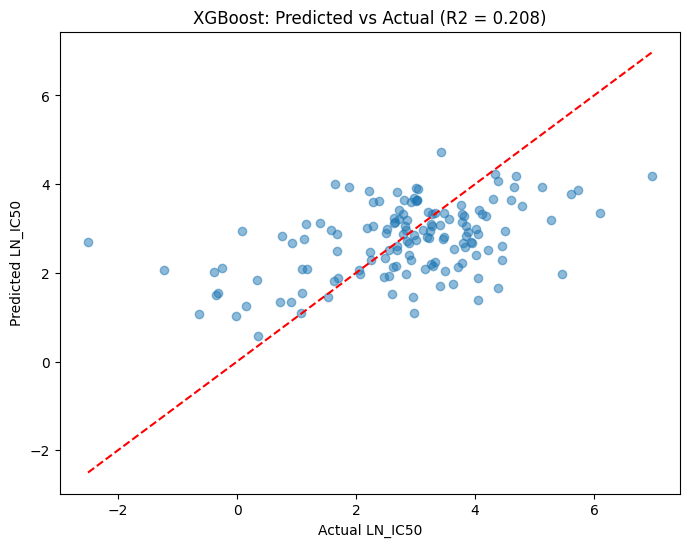

In [6]:
%matplotlib inline

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual LN_IC50')
plt.ylabel('Predicted LN_IC50')
plt.title(f'XGBoost: Predicted vs Actual (R2 = {r2:.3f})')
plt.show()

In [7]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV R2 scores: [0.35863166 0.18569876 0.15467511 0.09501973 0.17647113]
Mean CV R2: 0.1941 (+/- 0.0881)


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV R2: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV R2: 0.2218


In [9]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
corr_tuned, _ = pearsonr(y_test, y_pred_tuned)

print(f"Tuned MSE: {mse_tuned:.4f}")
print(f"Tuned R2: {r2_tuned:.4f}")
print(f"Tuned Pearson: {corr_tuned:.4f}")

Tuned MSE: 1.7817
Tuned R2: 0.1849
Tuned Pearson: 0.4391


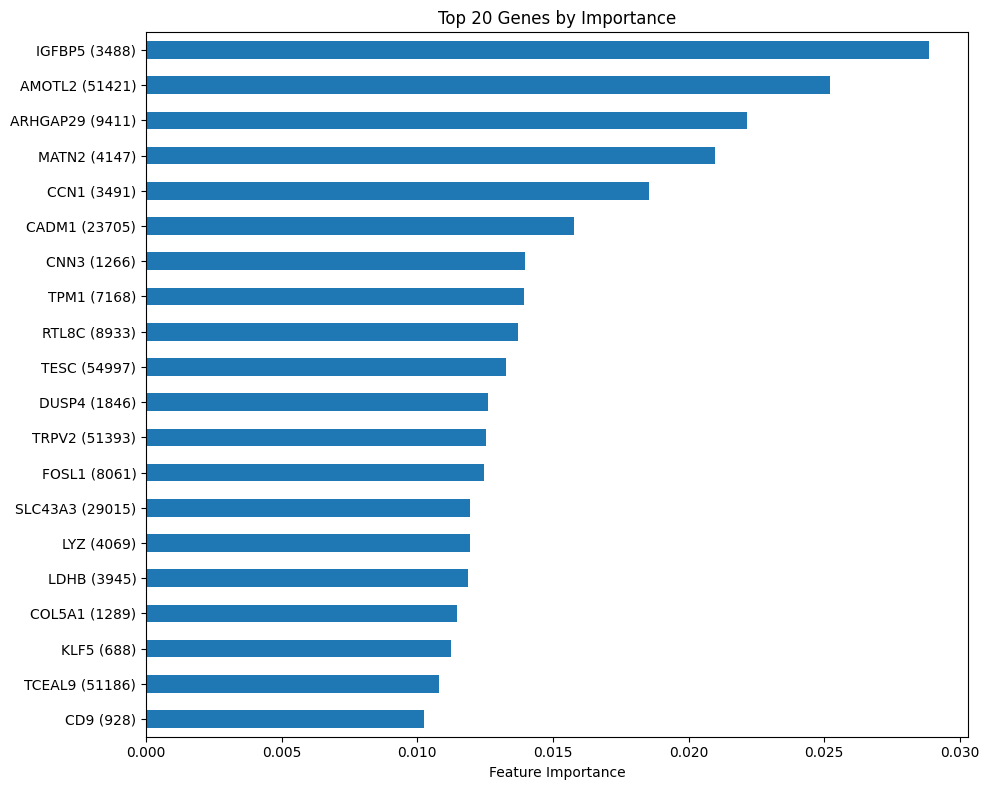

In [10]:
importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top_20.plot(kind='barh')
plt.xlabel('Feature Importance')
plt.title('Top 20 Genes by Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/xgboost_model.joblib')
print("Model saved")

Model saved


In [12]:
print("="*50)
print("XGBOOST MODEL SUMMARY")
print("="*50)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Features: {X_train.shape[1]}")
print(f"Test R2: {r2_tuned:.4f}")
print(f"Test Pearson: {corr_tuned:.4f}")
print("="*50)

XGBOOST MODEL SUMMARY
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Training samples: 567
Test samples: 142
Features: 1000
Test R2: 0.1849
Test Pearson: 0.4391
